In [4]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

sns.set(style="whitegrid")

# Sample DataFrame
#data = {'ingredients': ['chicken, pasta, pesto', 'chicken, tomato, onion', 'pasta, onion, garlic']}
df = pd.read_csv('indian_food.csv')

df['ingredients'] = df['ingredients'].str.lower()

df['ingredients'] = df['ingredients'].str.replace("garam masala powder", "garam masala")

df['ingredients'] = df['ingredients'].str.replace("clarified butter", "ghee")

df['ingredients'] = df['ingredients'].str.replace("khus-khus seed", "khus khus")

df['ingredients'] = df['ingredients'].str.replace("khus khuss", "khus khus")

df['ingredients'] = df['ingredients'].str.replace("red chilli", "red chili")

df['ingredients'] = df['ingredients'].str.replace("red chilies", "red chili")

df['ingredients'] = df['ingredients'].str.replace("mustard seed", "mustard seeds")

df['ingredients'] = df['ingredients'].str.replace("potatoes", "potato")

df['ingredients'] = df['ingredients'].str.replace("yoghurt", "yogurt")

df['ingredients'] = df['ingredients'].str.replace("almond", "almonds")

df['ingredients'] = df['ingredients'].str.replace("almondss", "almonds")

df['ingredients'] = df['ingredients'].str.replace("mustard seedss", "mustard seeds")


df['ingredients'] = df['ingredients'].str.replace("carrots", "carrot")



df['total_time'] = df['prep_time'] + df['cook_time']

# 1. Split the 'ingredients' column strings into lists
#    Use a lambda function with .strip() to remove leading/trailing whitespace
df['ingredients_list'] = df['ingredients'].apply(lambda x: [item.strip() for item in x.split(',')])

most_common = df['ingredients_list'].value_counts().idxmax()

#frequency = df['ingredients_list'].values[0]

#all_ingredients = []
#for ingredients in df['ingredients_list']:
 #   all_ingredients.extend(ingredients)

#ingredient_counts = Counter(all_ingredients)

# 2. Explode the list column to have one ingredient per row
exploded_ingredients = df.explode('ingredients_list')



# 3. Count the frequency of each unique ingredient
#    value_counts() returns a Series with ingredients as index and counts as values
ingredient_counts = exploded_ingredients['ingredients_list'].value_counts()

# 4. Convert the pandas Series to a dictionary
ingredients_dict = ingredient_counts.to_dict()

#sorted_ingr_dict = sorted(ingredients_dict.items())

sorted_ingr_dict = dict(sorted(ingredients_dict.items(), key=lambda item: item[1], reverse=True))

top_3 = sorted(ingredients_dict.items(), key=lambda x: x[1], reverse=True)[:3]


# Print the resulting dictionary
print(sorted_ingr_dict)

print("Most common ingredients:", top_3)

{'sugar': 48, 'garam masala': 40, 'ghee': 34, 'ginger': 29, 'urad dal': 25, 'curry leaves': 25, 'milk': 21, 'rice flour': 21, 'jaggery': 21, 'potato': 18, 'tomato': 16, 'chana dal': 16, 'gram flour': 13, 'mustard oil': 12, 'whole wheat flour': 12, 'wheat flour': 12, 'coconut': 12, 'sesame seeds': 11, 'saffron': 10, 'rice': 10, 'mustard seeds': 10, 'yogurt': 10, 'turmeric': 10, 'cardamom': 9, 'semolina': 9, 'lemon juice': 8, 'garlic': 8, 'baking soda': 8, 'curd': 8, 'butter': 7, 'grated coconut': 7, 'all purpose flour': 7, 'tomatoes': 7, 'salt': 7, 'moong dal': 7, 'bengal gram flour': 7, 'coconut oil': 6, 'cream': 6, 'chhena': 6, 'lemon': 6, 'green chilies': 6, 'gur': 6, 'cashew nuts': 6, 'rava': 6, 'cinnamon': 6, 'green chili': 6, 'raisins': 6, 'chillies': 6, 'chicken': 6, 'red chili': 6, 'kasuri methi': 6, 'olive oil': 5, 'hot water': 5, 'cashews': 5, 'chili powder': 5, 'carrot': 5, 'oil': 5, 'arhar dal': 5, 'green peas': 5, 'tamarind': 5, 'black pepper': 5, 'cottage cheese': 5, 'nuts

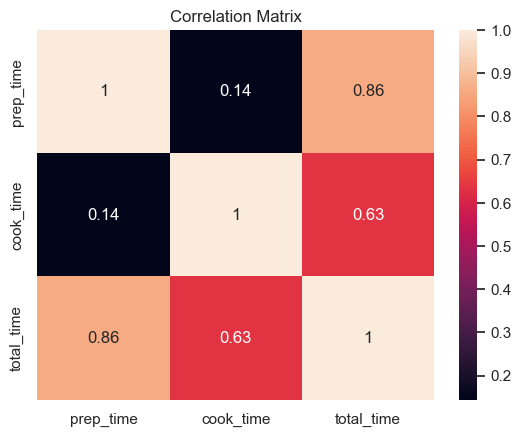

In [7]:
plt.figure()
#sns.heatmap(df[["prep_time", "cook_time", "total_time", "ingredient_counts"]].corr(), annot=True)
sns.heatmap(df[["prep_time", "cook_time", "total_time"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

**The correlation heatmap measures nullity correlation: how strongly the presence or absence of one variable affects the presence of another. It ranges from -1 (if one variable appears the other definitely does not) to 0 (variables appearing or not appearing have no effect on one another) to 1 (if one variable appears the other definitely also does).**